In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


In [37]:


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

random_seed = 42

In [38]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential

In [39]:
data = load_breast_cancer(as_frame=True)

df = data.frame
X = df.drop(columns=['target']).to_numpy()
y = df['target'].to_numpy()

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed, stratify=y)


hwscaler = StandardScaler()
x_train_scaled = hwscaler.fit_transform(x_train)
x_test_scaled = hwscaler.transform(x_test)

---

# keras 1

In [40]:
model_baseline = keras.Sequential(
    [
       keras.layers.Input(shape=(x_train_scaled.shape[1],  )),     # Explicit input layer
       keras.layers.Dense(1, activation="sigmoid")
    ]
)


model_baseline.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
baseline_weight = class_weight.compute_class_weight(
    class_weight = 'balanced' ,
    classes = np.unique(y_train) ,
    y = y_train
)

baseline_class_weight_dict = dict(zip(np.unique(y_train), baseline_weight))
baseline_class_weight_dict

{np.int64(0): np.float64(1.338235294117647),
 np.int64(1): np.float64(0.7982456140350878)}

In [42]:
model_baseline.compile(
    optimizer='adam', 
    loss='mse',
    metrics = ['accuracy']
    ) 

In [43]:
n_epoch = 5

model_baseline_hx = model_baseline.fit(
    x_train_scaled, y_train, 
    epochs = n_epoch , 
    class_weight = baseline_class_weight_dict ,

    verbose = 1
)


Epoch 1/5


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6769 - loss: 0.2115
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7516 - loss: 0.1776
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8132 - loss: 0.1517
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8440 - loss: 0.1316 
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8725 - loss: 0.1158 


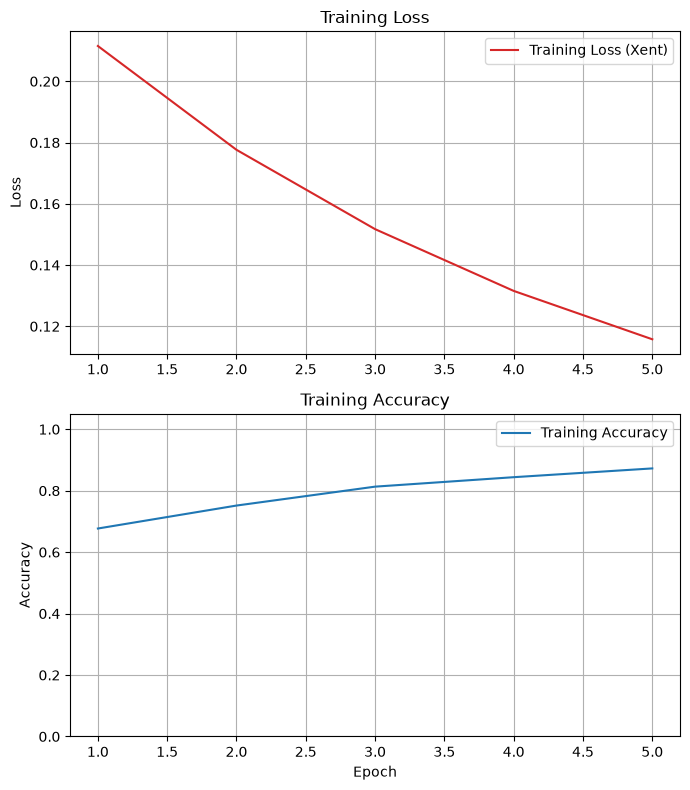

Final Training Loss:     0.1158
Final Training Accuracy: 0.8725


In [44]:


def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')


plot_history(model_baseline_hx)

In [45]:
print(f'{model_baseline_hx.history["accuracy"][-1]}')

0.8725274801254272


-----

# part d


In [50]:
test_loss, test_accuracy = model_baseline.evaluate(
	x_test_scaled
	, y_test
	, verbose = 1
)
print(test_loss, test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8860 - loss: 0.1138 
0.11378633230924606 0.8859649300575256


In [47]:

print(f"test loss: {test_loss}")

test loss: [0.11378633230924606, 0.8859649300575256]


----

# prob 2

In [51]:
n_epochs = 100


##_____ work _____ ##: 
model_p2 = keras.Sequential(
    [
       keras.layers.Input(shape=    (x_train_scaled.shape[1],  )),     
       keras.layers.Dense(16,       activation="sigmoid"),
       keras.layers.Dense(1,        activation="sigmoid")
    ]
)
display(model_p2.summary() )


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

None

Epoch 1/100


I0000 00:00:1788634424.905580    2168 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6793__.8


14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6295 - loss: 0.7425

I0000 00:00:1788634425.907475    2170 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6793__.8


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6264 - loss: 0.7447
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6725 - loss: 0.6240 
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7670 - loss: 0.5299 
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8549 - loss: 0.4640 
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8923 - loss: 0.4145
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9187 - loss: 0.3765 
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9297 - loss: 0.3463 
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9341 - loss: 0.3227 
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9407 - loss: 0.3021
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9429 - loss: 0.2845 
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9451 - loss: 0.2691
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9

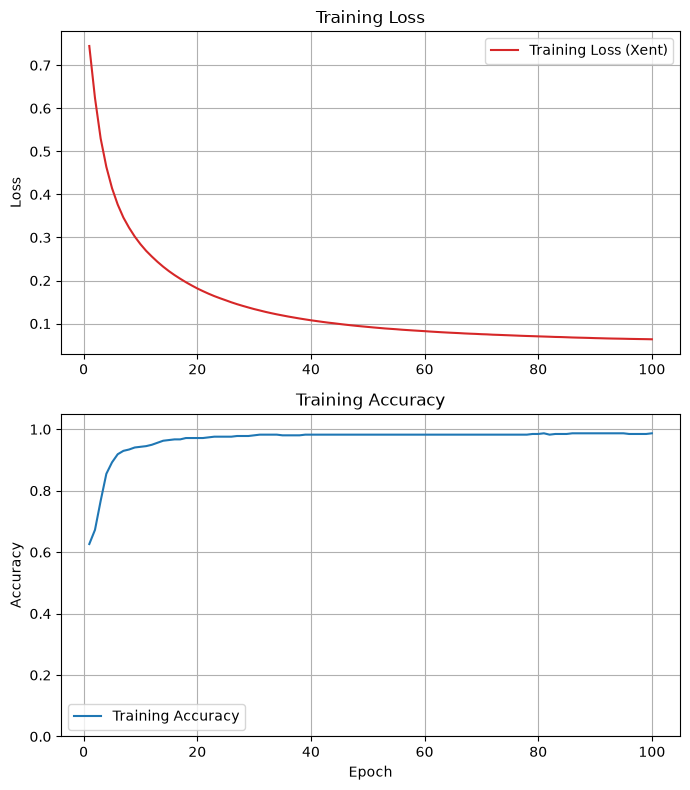

Final Training Loss:     0.0636
Final Training Accuracy: 0.9868


In [52]:


# baseline_weight = class_weight.compute_class_weight(
#     class_weight = 'balanced' ,
#     classes = np.unique(y_train) ,
#     y = y_train
# )
# baseline_class_weight_dict = dict(zip(np.unique(y_train), baseline_weight))
# baseline_class_weight_dict


model_p2.compile(
    optimizer='adam', 
    loss='binary_crossentropy',
    metrics = ['accuracy']
    ) 

model_p2_hx = model_p2.fit(
    x_train_scaled, y_train, 
    epochs = n_epochs , 
    class_weight = baseline_class_weight_dict ,
    verbose = 1
)


plot_history(model_p2_hx)

In [53]:
print(f'{model_p2_hx.history["accuracy"][-1]}')

0.9868131875991821


In [ ]:
model_p2_hx.history["accuracy"][-1] 

p2_test_accuracy